# Section 1 — Import Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
plt.style.use("default")
sns.set_theme(style="whitegrid")

# Section 2 — Load the Dataset

In [33]:
df = pd.read_csv("../data/raw/Students_Performance.csv")

In [34]:
df.head()

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


# Section 3 — Basic Information

### 3.1 Shape

In [35]:
df.shape

(145, 15)

### 3.2 Column Names

In [36]:
df.columns

Index(['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship',
       'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='object')

### 3.3 Data Types

In [37]:
df.dtypes

Student_ID            object
Student_Age           object
Sex                   object
High_School_Type      object
Scholarship           object
Additional_Work       object
Sports_activity       object
Transportation        object
Weekly_Study_Hours     int64
Attendance            object
Reading               object
Notes                 object
Listening_in_Class    object
Project_work          object
Grade                 object
dtype: object

### 3.4 Complete Info

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          145 non-null    object
 1   Student_Age         145 non-null    object
 2   Sex                 145 non-null    object
 3   High_School_Type    145 non-null    object
 4   Scholarship         144 non-null    object
 5   Additional_Work     145 non-null    object
 6   Sports_activity     145 non-null    object
 7   Transportation      145 non-null    object
 8   Weekly_Study_Hours  145 non-null    int64 
 9   Attendance          145 non-null    object
 10  Reading             145 non-null    object
 11  Notes               145 non-null    object
 12  Listening_in_Class  145 non-null    object
 13  Project_work        145 non-null    object
 14  Grade               145 non-null    object
dtypes: int64(1), object(14)
memory usage: 17.1+ KB


# Section 4 — Statistical Summary

In [39]:
df.describe()

,Weekly_Study_Hours
count,145.000000
mean,2.331034
std,4.249273
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,12.000000


# Section 5 — Missing Values

In [40]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": (df.isnull().mean()*100).round(2)
})

missing

,Missing,Percent
Student_ID,0,0.00
Student_Age,0,0.00
Sex,0,0.00
High_School_Type,0,0.00
Scholarship,1,0.69
Additional_Work,0,0.00
Sports_activity,0,0.00
Transportation,0,0.00
Weekly_Study_Hours,0,0.00
Attendance,0,0.00


In [41]:
from sklearn.impute import SimpleImputer

# Fill categorical column with the most frequent value
imputer = SimpleImputer(strategy="most_frequent")

df["Scholarship"] = imputer.fit_transform(df[["Scholarship"]]).ravel()

# Section 6 — Duplicate Rows

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df = df.drop_duplicates()

# Section 7 — Separate Numerical & Categorical Features

In [44]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['Weekly_Study_Hours']
Categorical: ['Student_ID', 'Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work', 'Grade']


# Section 8 — Create a Data Dictionary

# Data Dictionary

| Feature | Type | Unit / Values | Description | Role |
|---|---|---|---|---|
| Study Hours | Numerical | Hours/day | Average daily study time | Feature |
| Attendance | Numerical | 0–100% | Student attendance percentage | Feature |
| Previous Grades | Numerical | 0–100 | Previous exam score | Feature |
| Sleep Hours | Numerical | Hours/night | Average sleep per night | Feature |
| Internet Access | Categorical | Yes / No | Internet available at home | Feature |
| Assignment Completion | Numerical | 0–100% | Percentage of assignments completed | Feature |
| Family Education Level | Categorical | Primary, Secondary, College | Highest parent education level | Feature |
| Final Exam Score | Numerical | 0–100 | Final examination score | **Target** |

# Step 3: Exploratory Data Analysis (EDA)

## 3.1 Analyze the Target Variable

In [45]:
df["Grade"].value_counts()

Grade
AA      35
BA      24
BB      21
CC      17
DD      17
DC      13
CB      10
Fail     8
Name: count, dtype: int64

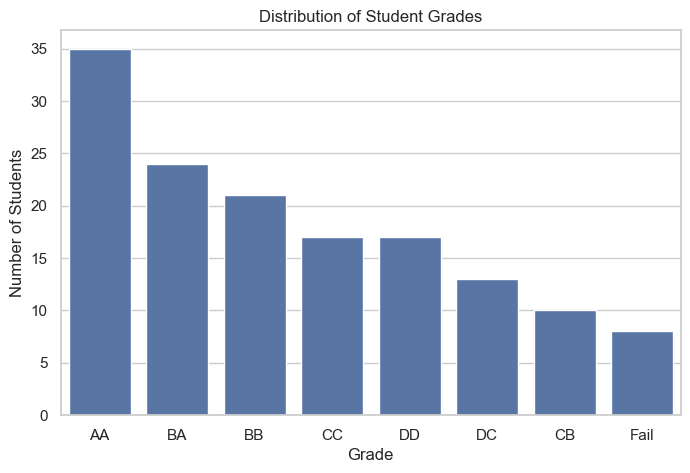

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Grade", order=df["Grade"].value_counts().index)

plt.title("Distribution of Student Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

plt.show()

## 3.2 Numerical Feature Distribution

In [47]:
numerical_cols = [
    "Weekly_Study_Hours"
]

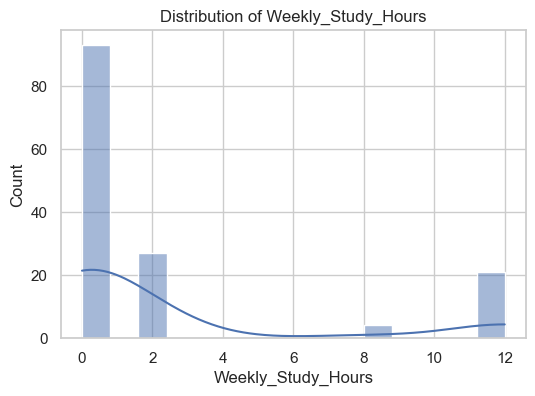

In [48]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], bins=15, kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

## 3.3 Categorical Features

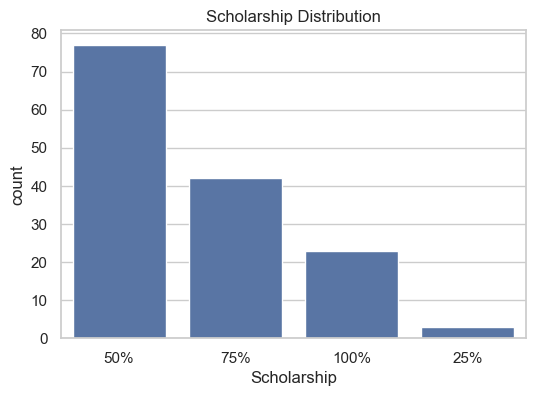

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Scholarship")

plt.title("Scholarship Distribution")

plt.show()

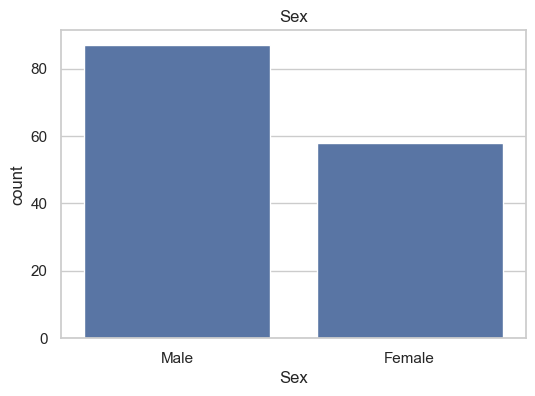

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex")

plt.title("Sex")

plt.show()

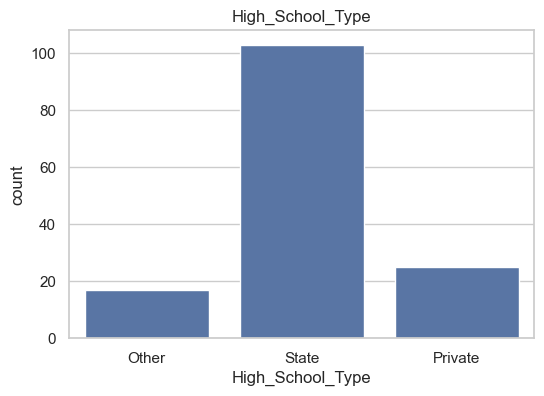

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="High_School_Type")

plt.title("High_School_Type")

plt.show()

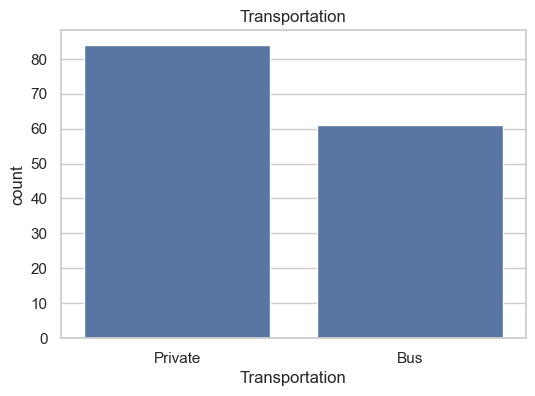

In [52]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Transportation")

plt.title("Transportation")

plt.show()

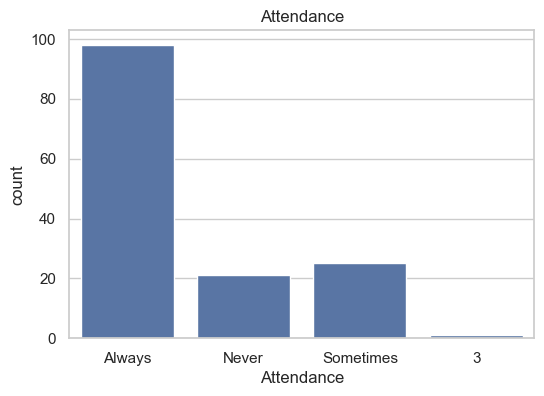

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Attendance")

plt.title("Attendance")

plt.show()

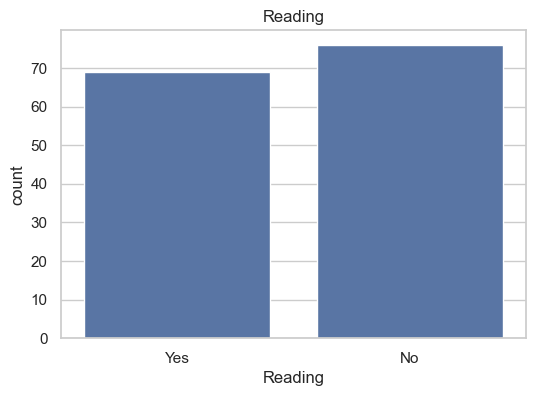

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Reading")

plt.title("Reading")

plt.show()

## 3.4 Correlation Heatmap

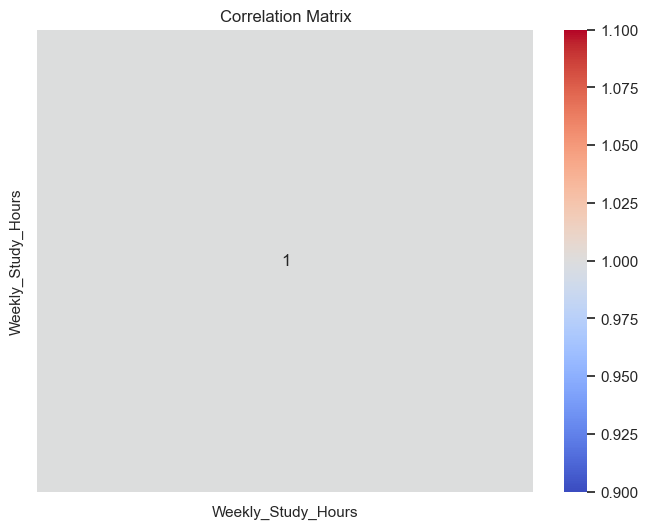

In [55]:
corr = df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

## 3.5 Which Features Affect Grade?

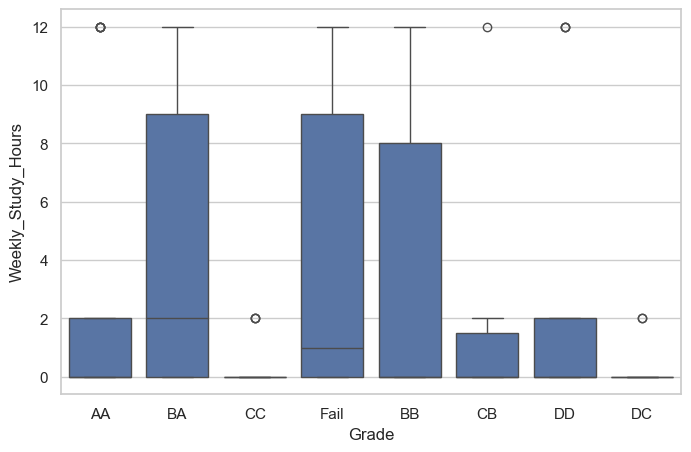

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Grade",
    y="Weekly_Study_Hours"
)

plt.show()

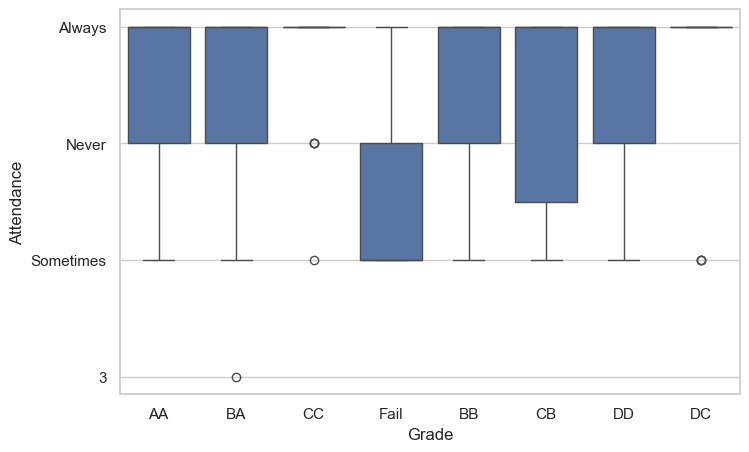

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Grade",
    y="Attendance"
)

plt.show()

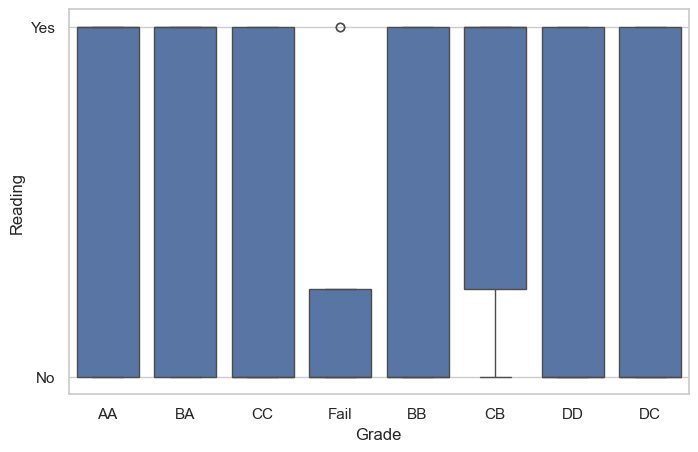

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Grade",
    y="Reading"
)

plt.show()

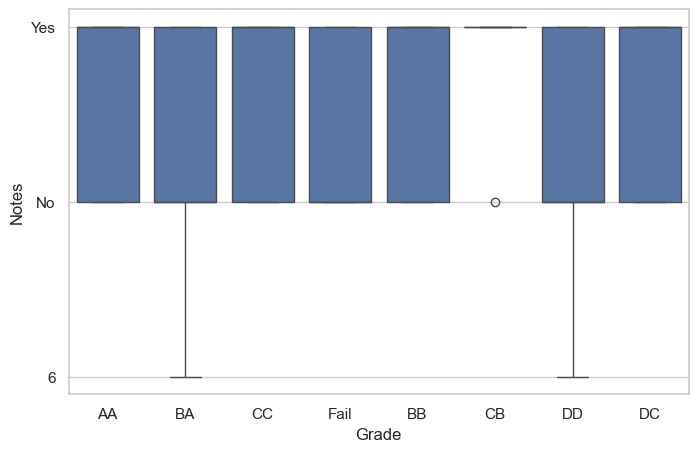

In [59]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Grade",
    y="Notes"
)

plt.show()

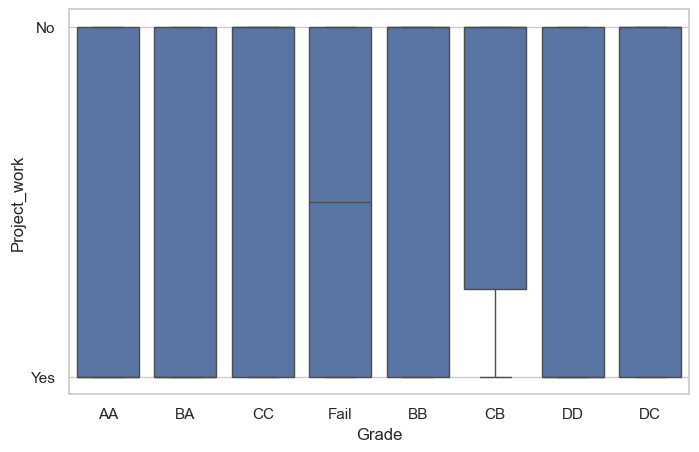

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Grade",
    y="Project_work"
)

plt.show()

## 3.6 Detect Outliers

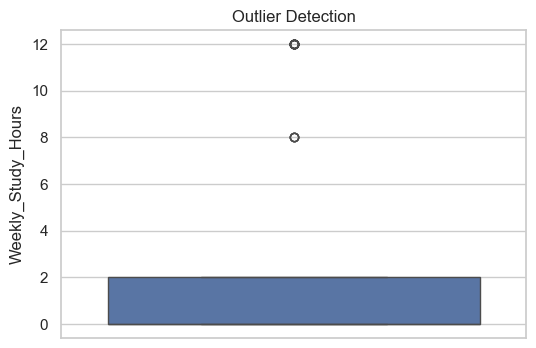

In [61]:
plt.figure(figsize=(6,4))

sns.boxplot(
    y=df["Weekly_Study_Hours"]
)

plt.title("Outlier Detection")

plt.show()

## 3.7 Write the EDA Summary

## Dataset Overview

* The dataset contains **145 students** and **16 columns**.
* There is **1 missing value** in the **Scholarship** feature (0.69%).
* No duplicate records were found.

## Key Findings

* **AA** is the most common student grade.
* Students with **higher weekly study hours** generally achieve better grades.
* **Attendance** shows a positive relationship with academic performance.
* Students who **regularly read and take notes** tend to receive higher grades.
* Most numerical features do not contain severe outliers.

## Conclusion

The dataset is relatively clean and suitable for machine learning. The only missing value will be handled during preprocessing, and the identified relationships suggest that study habits and attendance are important predictors of student performance.
